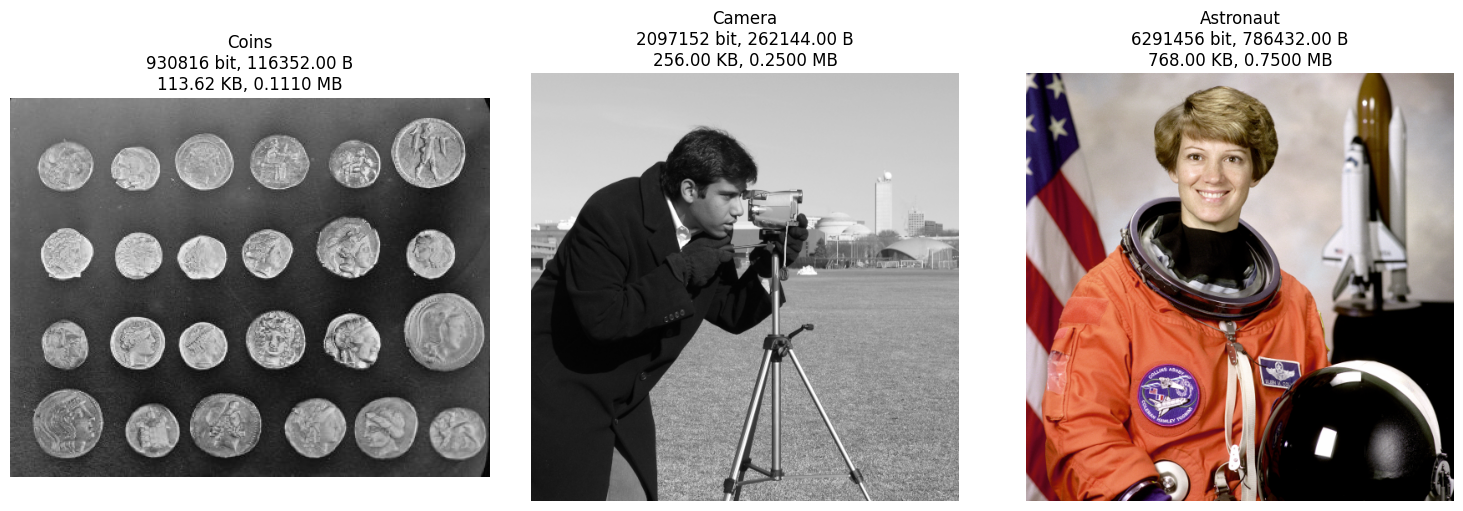

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Contoh gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menghitung ukuran gambar
def hitung_ukuran(image):
    bit_per_pixel = 8 if len(image.shape) == 2 else 24  # Grayscale = 8 bit, RGB = 24 bit
    total_pixels = image.shape[0] * image.shape[1]
    total_bits = total_pixels * bit_per_pixel
    total_bytes = total_bits / 8
    total_kb = total_bytes / 1024
    total_mb = total_kb / 1024
    return total_bits, total_bytes, total_kb, total_mb

# Menyusun gambar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    bits, bytes_, kb, mb = hitung_ukuran(img)
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\n{bits} bit, {bytes_:.2f} B\n{kb:.2f} KB, {mb:.4f} MB")
    ax.axis('off')

plt.tight_layout()
plt.show()

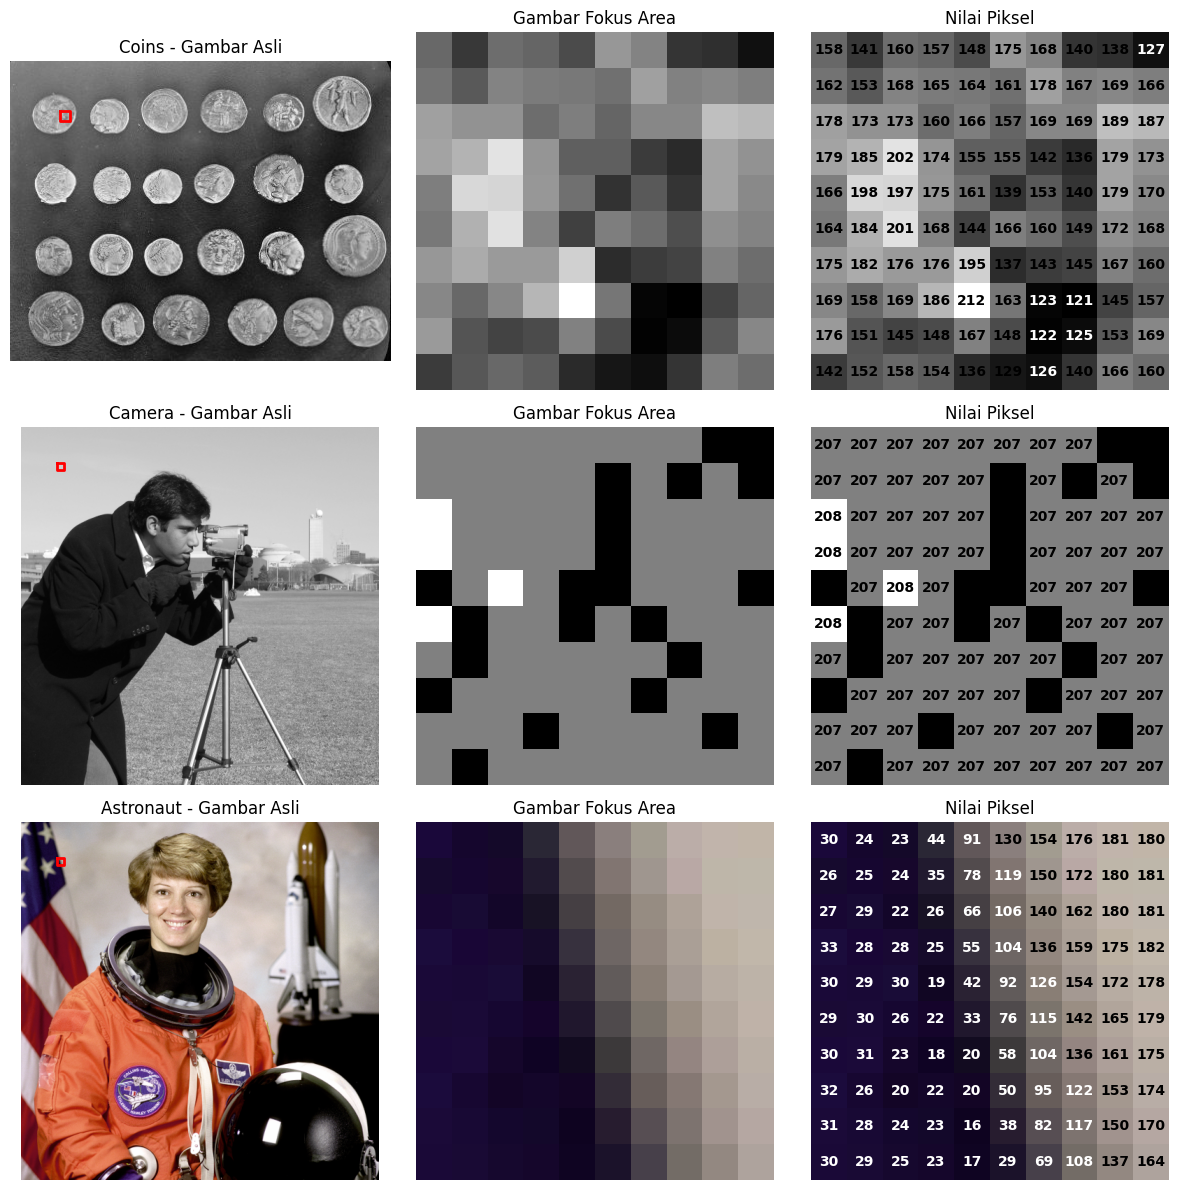

In [8]:
# Menampilkan bagaimana citra digital tersusun dari piksel dengan area fokus yang ditandai

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

x_start, x_end = 50, 60
y_start, y_end = 50, 60

for i, (img, nama) in enumerate(zip(gambar_list, nama_list)):
    # Gambar asli
    axes[i, 0].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    axes[i, 0].set_title(f"{nama} - Gambar Asli")
    axes[i, 0].axis('off')

    # Kotak merah
    rect_x = [x_start, x_end, x_end, x_start, x_start]
    rect_y = [y_start, y_start, y_end, y_end, y_start]
    axes[i, 0].plot(rect_x, rect_y, color="red", linewidth=2)

    # Zoom area
    zoomed_img = img[y_start:y_end, x_start:x_end]
    axes[i, 1].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')
    axes[i, 1].set_title("Gambar Fokus Area")
    axes[i, 1].axis('off')

    # Nilai piksel
    axes[i, 2].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')

    for y in range(zoomed_img.shape[0]):
        for x in range(zoomed_img.shape[1]):
            if len(img.shape) == 3:
                pixel_value = int(np.mean(zoomed_img[y, x]))
            else:
                pixel_value = zoomed_img[y, x]

            text_color = "white" if pixel_value < 128 else "black"
            axes[i, 2].text(x, y, str(pixel_value),
                            color=text_color,
                            ha='center', va='center',
                            fontsize=10, fontweight='bold')

    axes[i, 2].set_title("Nilai Piksel")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


=== Coins ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (303, 384)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[ 47 123 133 129 137]
 [ 93 144 145 143 145]
 [126 147 143 147 145]
 [131 136 133 139 136]
 [131 133 134 135 129]]

=== Camera ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (512, 512)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[200 200 200 200 199]
 [200 199 199 200 199]
 [199 199 199 200 200]
 [200 200 199 199 199]
 [200 200 200 200 199]]

=== Astronaut ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (512, 512, 3)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[[154 147 151]
  [109 103 124]
  [ 63  58 102]
  [ 54  51  98]
  [ 76  76 106]]

 [[177 171 171]
  [144 141 143]
  [113 114 124]
  [106 107 120]
  [128 128 131]]

 [[201 194 193]
  [182 178 175]
  [168 165 164]
  [159 157 157]
  [167 165 161]]

 [[220 213 210]
  [214 206 206]
  [202 198 196]
  [197 191 193]
  [200 194 196]]

 [[232 223 223]
  [226 220 215]
  [221 215

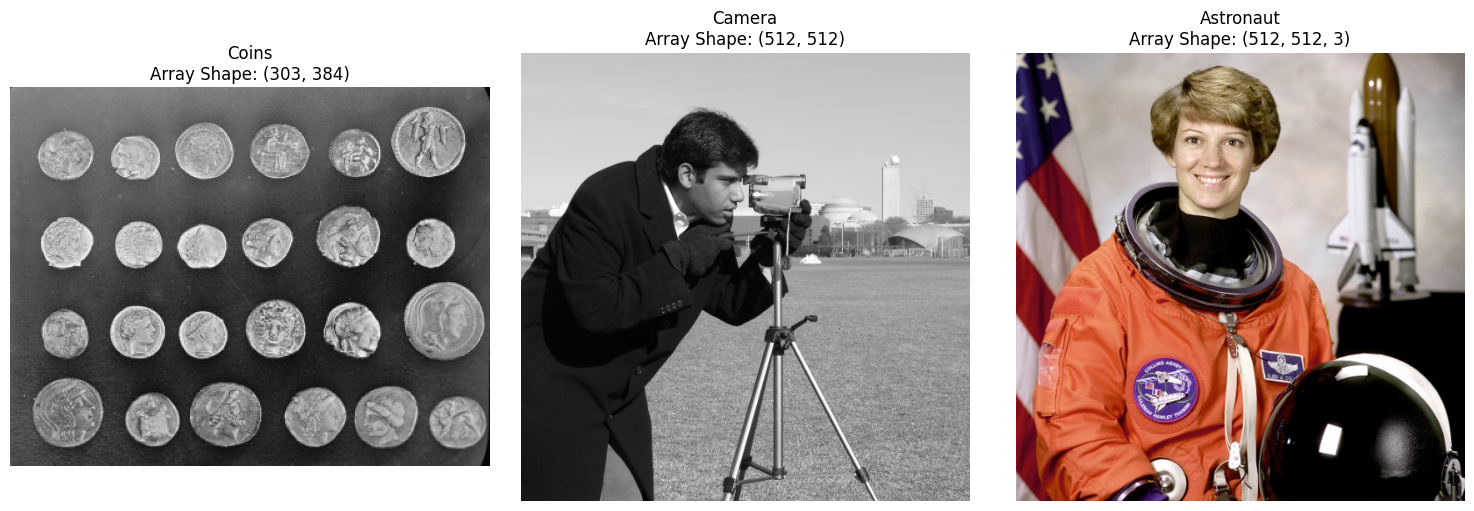

In [9]:
# Menjelaskan bagaimana citra disimpan dalam array NumPy

import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Memuat gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menampilkan informasi array NumPy dari gambar
def info_array_numpy(image, nama):
    print(f"\n=== {nama} ===")
    print(f"Tipe Data: {type(image)}")  # <class 'numpy.ndarray'>
    print(f"Dimensi: {image.shape}")   # (height, width) atau (height, width, channel)
    print(f"Tipe Nilai Piksel: {image.dtype}")  # biasanya uint8

    # Menampilkan sebagian kecil array (5x5 piksel pertama)
    print("Contoh nilai piksel (5x5 pertama):")
    if len(image.shape) == 2:
        print(image[:5, :5])
    else:
        print(image[:5, :5, :])

# Menampilkan informasi setiap gambar
info_array_numpy(gambar_coins, "Coins")
info_array_numpy(gambar_camera, "Camera")
info_array_numpy(gambar_astronaut, "Astronaut")

# Visualisasi gambar + shape array
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\nArray Shape: {img.shape}")
    ax.axis('off')

plt.tight_layout()
plt.show()

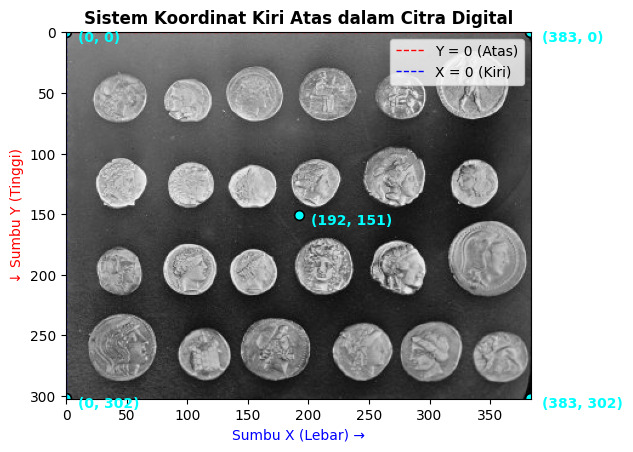

In [10]:
# Menjelaskan sistem koordinat kiri atas dalam citra digital

import matplotlib.pyplot as plt
from skimage import data

# Pilih salah satu gambar
gambar_sample = data.coins()

# Ukuran gambar
height, width = gambar_sample.shape

# Buat plot
fig, ax = plt.subplots(figsize=(6, 6))

# Tampilkan gambar
ax.imshow(gambar_sample, cmap='gray')

# Judul dan label sumbu
ax.set_title("Sistem Koordinat Kiri Atas dalam Citra Digital",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Sumbu X (Lebar) →", fontsize=10, color="blue")
ax.set_ylabel("↓ Sumbu Y (Tinggi)", fontsize=10, color="red")

# Garis koordinat utama
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label="Y = 0 (Atas)")
ax.axvline(x=0, color='blue', linestyle='--', linewidth=1, label="X = 0 (Kiri)")

# Titik-titik koordinat penting
koordinat_titik = [
    (0, 0),
    (width - 1, 0),
    (0, height - 1),
    (width - 1, height - 1),
    (width // 2, height // 2)
]

for x, y in koordinat_titik:
    ax.scatter(x, y, color='cyan', s=50, edgecolors='black', linewidth=1.2)
    ax.text(x + 10, y + 10, f"({x}, {y})",
            color="cyan", fontsize=10, fontweight="bold",
            ha="left", va="bottom")

# Legend
ax.legend(loc="upper right")

plt.show()

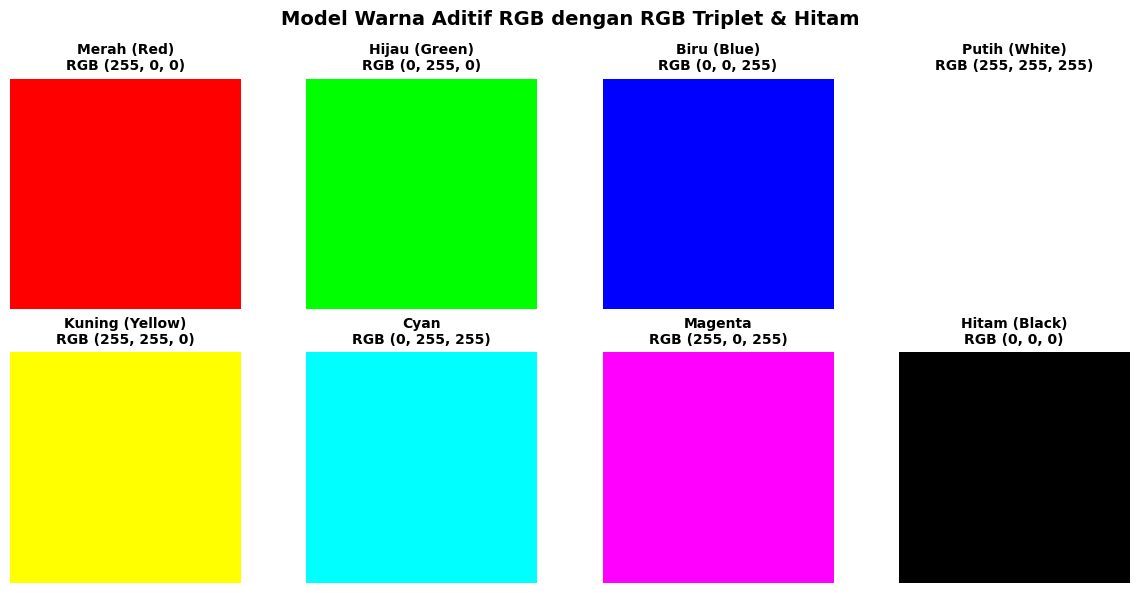

In [11]:
# Menjelaskan model warna aditif RGB dalam citra digital

import numpy as np
import matplotlib.pyplot as plt

# Membuat tiga kanal warna utama dalam model RGB
red_channel = np.zeros((100, 100, 3), dtype=np.uint8)
green_channel = np.zeros((100, 100, 3), dtype=np.uint8)
blue_channel = np.zeros((100, 100, 3), dtype=np.uint8)

# Mengatur warna merah, hijau, dan biru murni
red_channel[:, :, 0] = 255      # (255, 0, 0) - Merah
green_channel[:, :, 1] = 255    # (0, 255, 0) - Hijau
blue_channel[:, :, 2] = 255     # (0, 0, 255) - Biru

# Membuat kombinasi warna RGB
yellow = red_channel + green_channel       # (255, 255, 0)
cyan = green_channel + blue_channel        # (0, 255, 255)
magenta = red_channel + blue_channel       # (255, 0, 255)
white = red_channel + green_channel + blue_channel  # (255, 255, 255)
black = np.zeros((100, 100, 3), dtype=np.uint8)     # (0, 0, 0)

# Menampilkan hasil
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

color_list = [red_channel, green_channel, blue_channel, white,
              yellow, cyan, magenta, black]

color_names = ["Merah (Red)", "Hijau (Green)", "Biru (Blue)", "Putih (White)",
               "Kuning (Yellow)", "Cyan", "Magenta", "Hitam (Black)"]

rgb_values = ["(255, 0, 0)", "(0, 255, 0)", "(0, 0, 255)", "(255, 255, 255)",
              "(255, 255, 0)", "(0, 255, 255)", "(255, 0, 255)", "(0, 0, 0)"]

for ax, color, name, rgb in zip(axes.flat, color_list, color_names, rgb_values):
    ax.imshow(color)
    ax.set_title(f"{name}\nRGB {rgb}", fontsize=10, fontweight="bold")
    ax.axis('off')

plt.suptitle("Model Warna Aditif RGB dengan RGB Triplet & Hitam",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

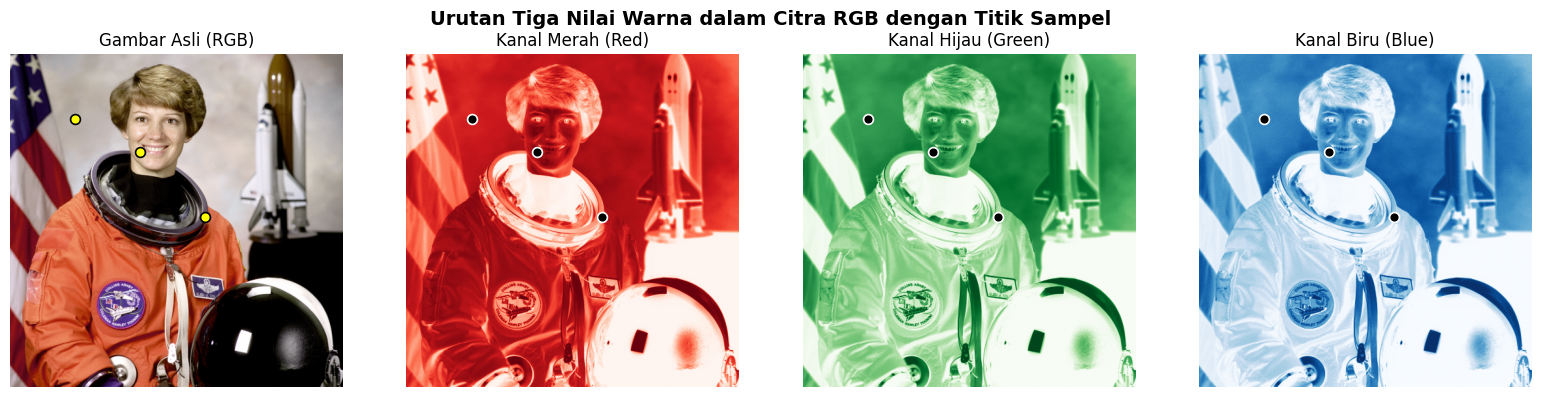

Nilai RGB pada titik koordinat yang dipilih:
Titik 1 - Koordinat (100, 100):
 Red (Merah) : 187
 Green (Hijau) : 176
 Blue (Biru) : 169
 RGB Triplet : (187, 176, 169)

Titik 2 - Koordinat (200, 150):
 Red (Merah) : 236
 Green (Hijau) : 210
 Blue (Biru) : 184
 RGB Triplet : (236, 210, 184)

Titik 3 - Koordinat (300, 250):
 Red (Merah) : 96
 Green (Hijau) : 76
 Blue (Biru) : 93
 RGB Triplet : (96, 76, 93)



In [12]:
# Menjelaskan urutan tiga nilai warna dalam citra RGB

import matplotlib.pyplot as plt
from skimage import data

# Memuat gambar RGB
gambar_rgb = data.astronaut()

# Ekstrak kanal warna
red_channel = gambar_rgb[:, :, 0]
green_channel = gambar_rgb[:, :, 1]
blue_channel = gambar_rgb[:, :, 2]

# Titik koordinat sampel
titik_koordinat = [(100, 100), (200, 150), (300, 250)]

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Gambar asli
axes[0].imshow(gambar_rgb)
axes[0].set_title("Gambar Asli (RGB)")
for x, y in titik_koordinat:
    axes[0].scatter(x, y, color='yellow', s=50, edgecolors='black', linewidth=1.2)

# Kanal merah
axes[1].imshow(red_channel, cmap="Reds")
axes[1].set_title("Kanal Merah (Red)")
for x, y in titik_koordinat:
    axes[1].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Kanal hijau
axes[2].imshow(green_channel, cmap="Greens")
axes[2].set_title("Kanal Hijau (Green)")
for x, y in titik_koordinat:
    axes[2].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Kanal biru
axes[3].imshow(blue_channel, cmap="Blues")
axes[3].set_title("Kanal Biru (Blue)")
for x, y in titik_koordinat:
    axes[3].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Hilangkan sumbu
for ax in axes:
    ax.axis("off")

plt.suptitle("Urutan Tiga Nilai Warna dalam Citra RGB dengan Titik Sampel",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# Menampilkan nilai RGB
print("Nilai RGB pada titik koordinat yang dipilih:")
for i, (x, y) in enumerate(titik_koordinat):
    r_val = gambar_rgb[y, x, 0]
    g_val = gambar_rgb[y, x, 1]
    b_val = gambar_rgb[y, x, 2]

    print(f"Titik {i+1} - Koordinat ({x}, {y}):")
    print(f" Red (Merah) : {r_val}")
    print(f" Green (Hijau) : {g_val}")
    print(f" Blue (Biru) : {b_val}")
    print(f" RGB Triplet : ({r_val}, {g_val}, {b_val})\n")

/tmp/ipykernel_60711/253338248.py:10: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave("astronaut.jpg", gambar, quality=95)  # JPEG (lossy)


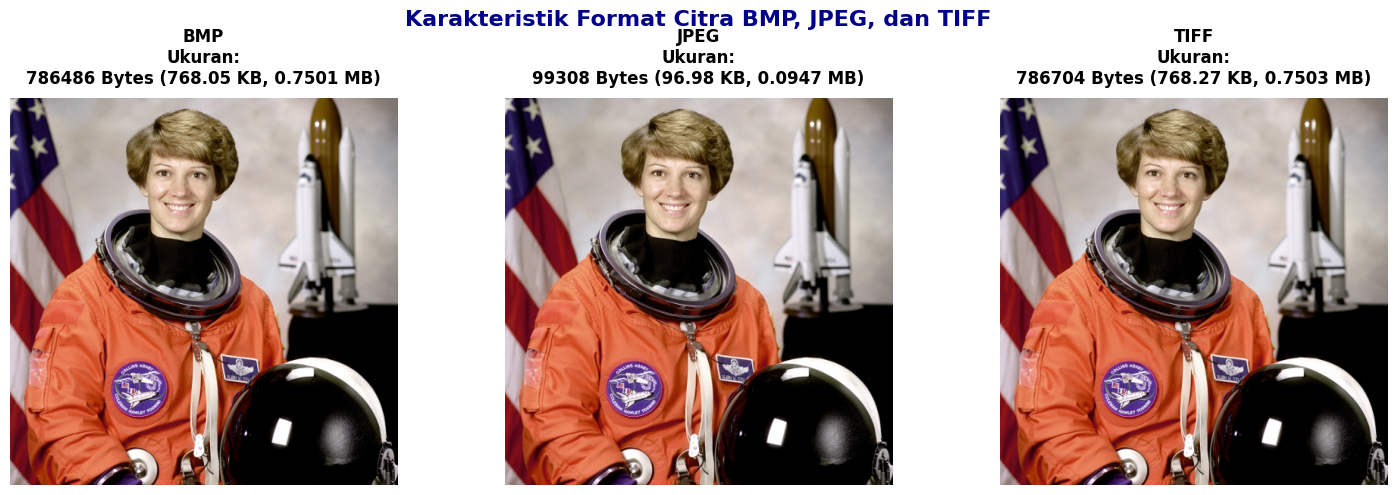

Karakteristik Format Citra:

1. BMP (Bitmap):
- Format tidak terkompresi, ukuran file besar.
- Kualitas sangat baik (tanpa kehilangan data).
- Cocok untuk pengolahan citra.
- Ukuran file: 786486 Bytes (768.05 KB, 0.7501 MB)

2. JPEG (Joint Photographic Experts Group):
- Format terkompresi lossy (ada kehilangan data).
- Ukuran file lebih kecil.
- Cocok untuk foto dan web.
- Ukuran file: 99308 Bytes (96.98 KB, 0.0947 MB)

3. TIFF (Tagged Image File Format):
- Bisa lossy atau lossless.
- Digunakan untuk kebutuhan profesional.
- Ukuran file relatif besar.
- Ukuran file: 786704 Bytes (768.27 KB, 0.7503 MB)


In [13]:
from skimage import io, data
import matplotlib.pyplot as plt
import os

# Membuat citra contoh
gambar = data.astronaut()

# Simpan gambar dalam berbagai format
io.imsave("astronaut.bmp", gambar)
io.imsave("astronaut.jpg", gambar, quality=95)  # JPEG (lossy)
io.imsave("astronaut.tiff", gambar)

# Fungsi menghitung ukuran file
def ukuran_file(nama_file):
    size_bytes = os.path.getsize(nama_file)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return f"{size_bytes} Bytes ({size_kb:.2f} KB, {size_mb:.4f} MB)"

# List format dan file
format_citra = ["BMP", "JPEG", "TIFF"]
nama_file = ["astronaut.bmp", "astronaut.jpg", "astronaut.tiff"]

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fmt, file in zip(axes, format_citra, nama_file):
    img = io.imread(file)
    ax.imshow(img)
    ax.set_title(f"{fmt}\nUkuran:\n{ukuran_file(file)}",
                 fontsize=12, fontweight="bold", color="black", pad=10)
    ax.axis("off")

plt.suptitle("Karakteristik Format Citra BMP, JPEG, dan TIFF",
             fontsize=16, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()

# Informasi karakteristik
print("Karakteristik Format Citra:")

print("\n1. BMP (Bitmap):")
print("- Format tidak terkompresi, ukuran file besar.")
print("- Kualitas sangat baik (tanpa kehilangan data).")
print("- Cocok untuk pengolahan citra.")
print(f"- Ukuran file: {ukuran_file(nama_file[0])}")

print("\n2. JPEG (Joint Photographic Experts Group):")
print("- Format terkompresi lossy (ada kehilangan data).")
print("- Ukuran file lebih kecil.")
print("- Cocok untuk foto dan web.")
print(f"- Ukuran file: {ukuran_file(nama_file[1])}")

print("\n3. TIFF (Tagged Image File Format):")
print("- Bisa lossy atau lossless.")
print("- Digunakan untuk kebutuhan profesional.")
print("- Ukuran file relatif besar.")
print(f"- Ukuran file: {ukuran_file(nama_file[2])}")


/tmp/ipykernel_60711/2833875452.py:22: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(jpeg_quality_50, gambar, quality=50)
/tmp/ipykernel_60711/2833875452.py:23: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(jpeg_quality_90, gambar, quality=90)


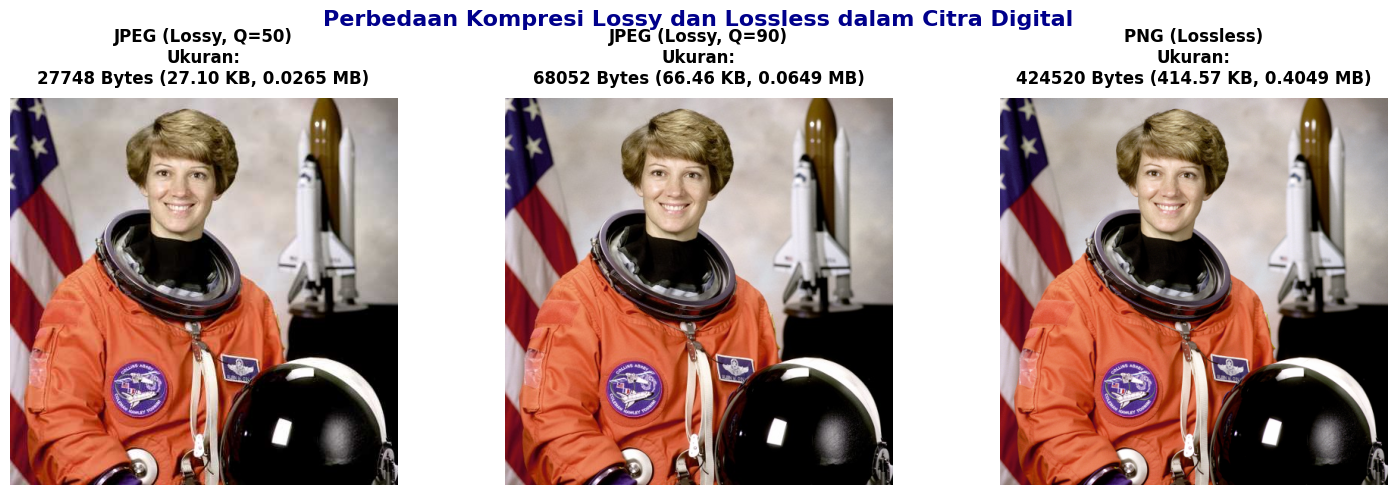

Perbedaan Kompresi Lossy dan Lossless:

1. JPEG (Lossy, Quality=50):
- Kompresi lossy kualitas rendah (Q=50).
- Detail gambar berkurang, muncul artefak.
- Ukuran file kecil.
- Ukuran file: 27748 Bytes (27.10 KB, 0.0265 MB)

2. JPEG (Lossy, Quality=90):
- Kompresi lossy kualitas tinggi (Q=90).
- Detail lebih baik, artefak lebih sedikit.
- Ukuran lebih besar dari Q=50.
- Ukuran file: 68052 Bytes (66.46 KB, 0.0649 MB)

3. PNG (Lossless):
- Kompresi tanpa kehilangan data.
- Kualitas sama dengan gambar asli.
- Ukuran file lebih besar dari JPEG.
- Ukuran file: 424520 Bytes (414.57 KB, 0.4049 MB)


In [14]:
# Menjelaskan perbedaan kompresi lossy dan lossless dalam citra digital

from skimage import io, data
import matplotlib.pyplot as plt
import os

# Load gambar
gambar = data.astronaut()

# Fungsi ukuran file
def ukuran_file(nama_file):
    size_bytes = os.path.getsize(nama_file)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return f"{size_bytes} Bytes ({size_kb:.2f} KB, {size_mb:.4f} MB)"

# Simpan gambar (lossy & lossless)
jpeg_quality_50 = "astronaut_lossy_50.jpg"
jpeg_quality_90 = "astronaut_lossy_90.jpg"
png_lossless = "astronaut_lossless.png"

io.imsave(jpeg_quality_50, gambar, quality=50)
io.imsave(jpeg_quality_90, gambar, quality=90)
io.imsave(png_lossless, gambar)

# List file
nama_file_kompresi = [jpeg_quality_50, jpeg_quality_90, png_lossless]

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

kompresi_label = [
    "JPEG (Lossy, Q=50)",
    "JPEG (Lossy, Q=90)",
    "PNG (Lossless)"
]

for ax, file, label in zip(axes, nama_file_kompresi, kompresi_label):
    img = io.imread(file)
    ax.imshow(img)
    ax.set_title(f"{label}\nUkuran:\n{ukuran_file(file)}",
                 fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")

plt.suptitle("Perbedaan Kompresi Lossy dan Lossless dalam Citra Digital",
             fontsize=16, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()

# Output teks
print("Perbedaan Kompresi Lossy dan Lossless:")

print("\n1. JPEG (Lossy, Quality=50):")
print("- Kompresi lossy kualitas rendah (Q=50).")
print("- Detail gambar berkurang, muncul artefak.")
print("- Ukuran file kecil.")
print(f"- Ukuran file: {ukuran_file(jpeg_quality_50)}")

print("\n2. JPEG (Lossy, Quality=90):")
print("- Kompresi lossy kualitas tinggi (Q=90).")
print("- Detail lebih baik, artefak lebih sedikit.")
print("- Ukuran lebih besar dari Q=50.")
print(f"- Ukuran file: {ukuran_file(jpeg_quality_90)}")

print("\n3. PNG (Lossless):")
print("- Kompresi tanpa kehilangan data.")
print("- Kualitas sama dengan gambar asli.")
print("- Ukuran file lebih besar dari JPEG.")
print(f"- Ukuran file: {ukuran_file(png_lossless)}")